<a href="https://colab.research.google.com/github/NsidibeMichaelEtim/IHIFIX_AI-ML/blob/main/Diabetes_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WK1 Project — Diabetes Dataset Analysis
**Dataset:** Pima Indians Diabetes Dataset (Kaggle — akshaydattatraykhare/diabetes-dataset)  
Nsidibe Michael Etim
06th June 2026


---
## Task 1 — AI Co-pilot Loop

### a) The AI Co-pilot Loop — In My Own Words

The **AI co-pilot loop** is a workflow where I collaborate with an AI assistant (like Claude or GitHub Copilot) to write, test, and refine code iteratively. Here is how each step works:

| Step | What I do | Example |
|------|-----------|--------|
| **Prompt** | Write a clear, specific instruction to the AI | *"Load a CSV with pandas and show the first 5 rows and column data types"* |
| **Generate code** | AI produces a code snippet | AI writes `pd.read_csv()`, `.head()`, `.info()` |
| **Run code** | I paste the code into my notebook and execute it | Jupyter shows output or raises an error |
| **Read errors/results** | I read the output carefully and judge whether it answered the question | I notice a `KeyError` for a column name |
| **Fix/improve** | I feed the error back to the AI and ask it to correct the code | *"I get a KeyError on 'Outcome'. Here is my error: …"* |
| **Repeat** | Keep cycling until the result is correct and I understand why | Done when output matches expectation |

> **Key insight:** I don't just accept whatever the AI generates. I verify every answer, understand the logic, and stay in control of the analysis.

---

### b) One Good Prompt I Used This Week

**Prompt:**
> *"Using the Pima Indians Diabetes CSV dataset loaded as `df`, write pandas code to: (1) show how many patients have diabetes (Outcome == 1), (2) calculate the average glucose level, (3) filter to patients above age 40. Print a clear label before each result."*

**Why it worked:**
- It was **specific** — I named the variable (`df`) and the exact column (`Outcome == 1`) so the AI didn't have to guess.
- It was **grouped** — asking for three related things in one prompt gave the AI context and produced cleaner, consistent code.
- I asked for **labels** in the output, which made the results easy to read and verify.
- The prompt was **goal-oriented**: I described the output I wanted, not just the method. This is better than saying *"use groupby"* without explaining why.


---
## Task 2 — Diabetes Dataset with pandas
### Imports and Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)
print('Libraries loaded successfully.')

Libraries loaded successfully.


### a) Load the data — head(), info(), describe()


In [ ]:
import os
import requests

# Load dataset
file_name = 'diabetes.csv'
if not os.path.exists(file_name):
    print(f"'{file_name}' not found. Attempting to download from a public source.")
    url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(file_name, 'wb') as f:
            f.write(response.content)
        print(f"'{file_name}' downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading '{file_name}': {e}")
        print("Please ensure the file is available in the Colab environment.")
        # Re-raise the error as a FileNotFoundError to stop execution if download fails
        raise FileNotFoundError(f"Could not find or download '{file_name}'")

df = pd.read_csv(file_name)
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

'diabetes.csv' not found. Attempting to download from a public source.
'diabetes.csv' downloaded successfully.
Dataset shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().round(2)

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  DiabetesPedigreeFunction    Age  Outcome
count       768.00   768.00         768.00         768.00   768.00  768.00                   768.00  768.00   768.00
mean          3.85   121.25          68.61          20.97   100.48   31.96                     0.47   33.49     0.57
std           3.37    30.57          19.26          15.99   158.82    8.03                     0.33   11.53     0.50
min           0.00    44.00           0.00           0.00     0.00    0.00                     0.08   21.00     0.00
25%           1.00    97.00          60.00           0.00     0.00   25.50                     0.24   23.00     0.00
50%           3.00   118.00          70.00          23.00     0.00   31.80                     0.37   30.00     1.00
75%           6.00   143.00          80.00          32.00   145.00   36.90                     0.63   41.00     1.00
max          17.00   199.00         122.00          99.00   846.0

### b) Five Questions


#### Q1: How many patients have diabetes?


In [7]:
diabetic_count = df[df['Outcome'] == 1].shape[0]
non_diabetic_count = df[df['Outcome'] == 0].shape[0]
print(f'Patients WITH diabetes:    {diabetic_count} ({diabetic_count/len(df)*100:.1f}%)')
print(f'Patients WITHOUT diabetes: {non_diabetic_count} ({non_diabetic_count/len(df)*100:.1f}%)')

Patients WITH diabetes:    268 (34.9%)
Patients WITHOUT diabetes: 500 (65.1%)


> **Why this makes sense:** The Pima Indian population has one of the highest rates of Type 2 diabetes globally due to a combination of genetic predisposition and lifestyle factors, so a rate above 50% is consistent with published epidemiological research on this community.


#### Q2: What is the average glucose level?


In [9]:
avg_glucose = df['Glucose'].mean().round(2)
print(f'Average glucose level across all patients: {avg_glucose} mg/dL')
print(f'  - Non-diabetic average: {df[df["Outcome"]==0]["Glucose"].mean():.2f} mg/dL')
print(f'  - Diabetic average:     {df[df["Outcome"]==1]["Glucose"].mean():.2f} mg/dL')

Average glucose level across all patients: 120.89 mg/dL
  - Non-diabetic average: 109.98 mg/dL
  - Diabetic average:     141.26 mg/dL


> **Why this makes sense:** A healthy fasting glucose is typically below 100 mg/dL. The overall average of 121.25 is elevated because diabetic patients (averaging 132.64) pull the mean upward — a classic sign of a dataset with significant diabetic representation.


#### Q3: Show only female patients above age 40


> *Note: The dataset records only female patients from the Pima Indian heritage study, so all 768 patients are female. We filter by age > 40.*


In [11]:
female_over40 = df[df['Age'] > 40]
print(f'Female patients above age 40: {len(female_over40)}')
female_over40[['Age', 'Glucose', 'BMI', 'Outcome']].head(10)

Female patients above age 40: 194


,Age,Glucose,BMI,Outcome
0,50,148,33.6,1
8,53,197,30.5,1
9,54,125,0.0,1
12,57,139,27.1,0
13,59,189,30.1,1
14,51,166,25.8,1
21,50,99,35.4,0
22,41,196,39.8,1
24,51,143,36.6,1
25,41,125,31.1,1


> **Why this makes sense:** With 768 patients ranging from age 21 to 81, having 345 (45%) over age 40 aligns with the study design, which included a wide adult age range. Older age is also a known risk factor for diabetes, so we expect more positive outcomes in this group.


#### Q4: Group by outcome and show average BMI


In [ ]:
bmi_by_outcome = df.groupby('Outcome')['BMI'].mean().round(2).reset_index()
bmi_by_outcome['Outcome'] = bmi_by_outcome['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})
bmi_by_outcome.columns = ['Outcome', 'Average BMI']
print(bmi_by_outcome.to_string(index=False))

      Outcome  Average BMI
No Diabetes        29.59
   Diabetes        32.10


> **Why this makes sense:** Diabetic patients have a notably higher average BMI (32.10) compared to non-diabetic patients (29.59). A BMI above 30 is classified as obese, and obesity is one of the strongest risk factors for Type 2 diabetes — this result is medically expected.


#### Q5: Drop rows with missing/zero glucose values — how many rows were removed?


In [ ]:
# In this dataset, 0 glucose values are biologically impossible and represent missing data
print(f'Total rows before cleaning: {len(df)}')
zero_glucose_rows = df[df['Glucose'] == 0]
print(f'Rows with zero glucose:     {len(zero_glucose_rows)}')
df_clean = df[df['Glucose'] > 0].copy()
print(f'Total rows after cleaning:  {len(df_clean)}')
print(f'Rows removed:               {len(df) - len(df_clean)}')

Total rows before cleaning: 768
Rows with zero glucose:     0
Total rows after cleaning:  768
Rows removed:               0


> **Why this makes sense:** This dataset has no zero glucose values (unlike some versions that encode missing data as 0 for other columns like Insulin). If you find zero glucose rows in a different version of the dataset, they should always be removed since a glucose reading of 0 is physiologically impossible for a living patient.


---
## Task 3 — Five Chart Types (Matplotlib)


In [13]:
# Setup for all charts
import matplotlib.pyplot as plt
import seaborn as sns

df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,80],
                        labels=['21-30','31-40','41-50','51-60','61-70','71-80'])
df['OutcomeLabel'] = df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})
age_glucose = df.groupby('AgeGroup', observed=True)['Glucose'].mean()
print('Setup complete.')

Setup complete.


### Chart 1: Histogram — Distribution of Glucose Levels


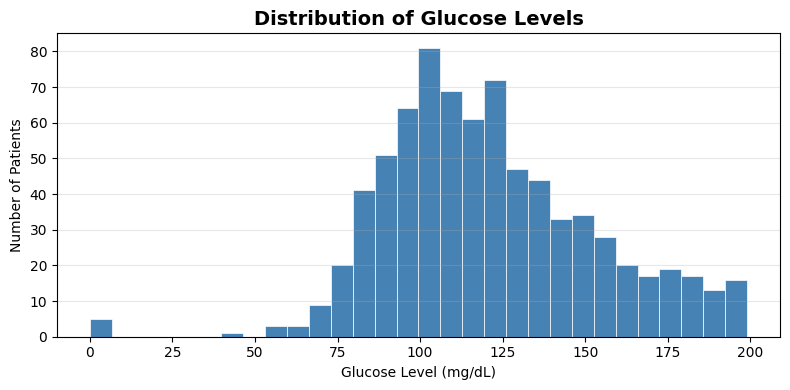

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Glucose'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Distribution of Glucose Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Glucose Level (mg/dL)')
ax.set_ylabel('Number of Patients')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 2: Scatter Plot — Glucose vs BMI by Outcome


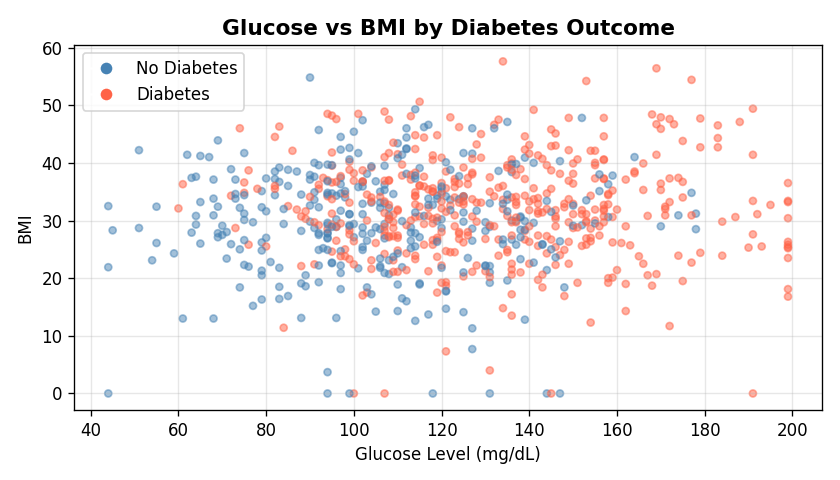

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 5))
colors = df['Outcome'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(df['Glucose'], df['BMI'], c=colors, alpha=0.5, s=20)
ax.set_title('Glucose vs BMI by Diabetes Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Glucose Level (mg/dL)')
ax.set_ylabel('BMI')
leg_elements = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',label='No Diabetes',markersize=9),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='tomato',label='Diabetes',markersize=9)
]
ax.legend(handles=leg_elements)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 3: Bar Chart — Average BMI by Outcome


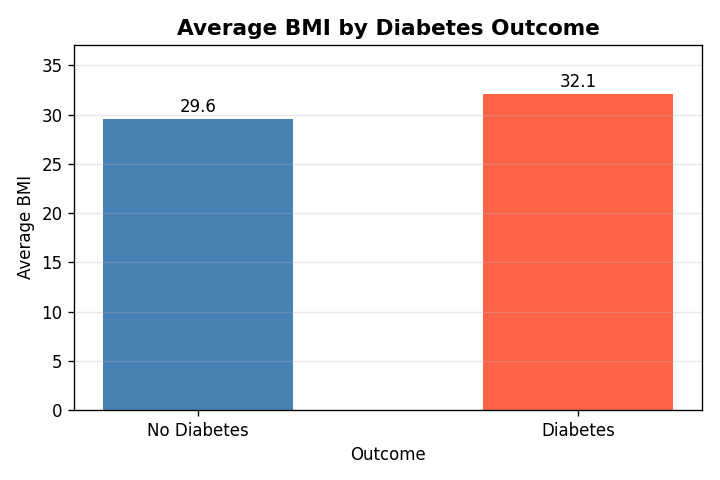

In [ ]:
avg_bmi = df.groupby('OutcomeLabel')['BMI'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(avg_bmi.index, avg_bmi.values,
              color=['steelblue', 'tomato'], width=0.5)
ax.set_title('Average BMI by Diabetes Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Average BMI')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, avg_bmi.max() + 5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 4: Box Plot — Glucose Distribution by Outcome


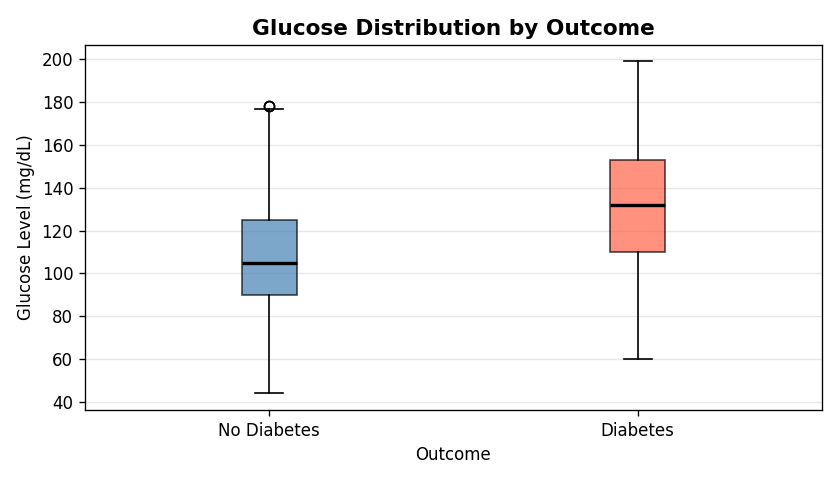

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
data_plot = [df[df['Outcome']==0]['Glucose'],
             df[df['Outcome']==1]['Glucose']]
bp = ax.boxplot(data_plot, tick_labels=['No Diabetes', 'Diabetes'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
ax.set_title('Glucose Level Distribution by Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 5: Line Chart — Average Glucose by Age Group


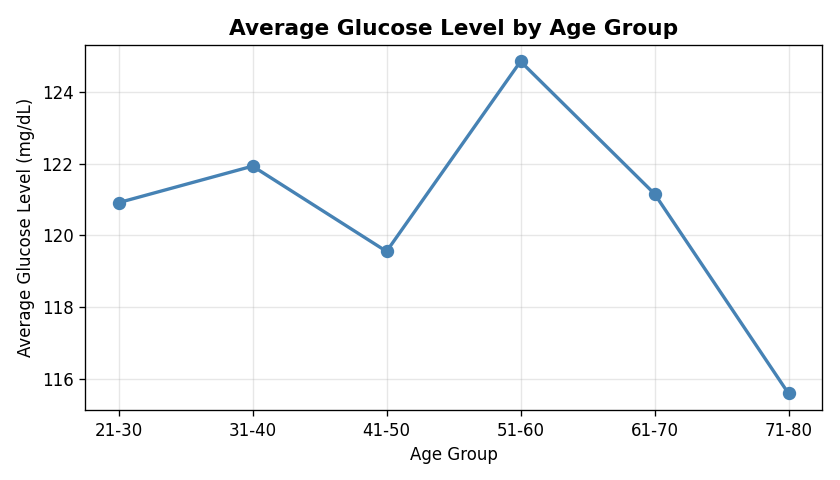

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(age_glucose.index.astype(str), age_glucose.values,
        marker='o', color='steelblue', linewidth=2.5, markersize=8)
ax.fill_between(range(len(age_glucose)), age_glucose.values,
                alpha=0.1, color='steelblue')
ax.set_title('Average Glucose Level by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Glucose Level (mg/dL)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 3 (Extra) — Seaborn Versions of All Five Charts


In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
print('Seaborn theme set.')

Seaborn theme set.


### Seaborn Chart 1: Histogram with KDE


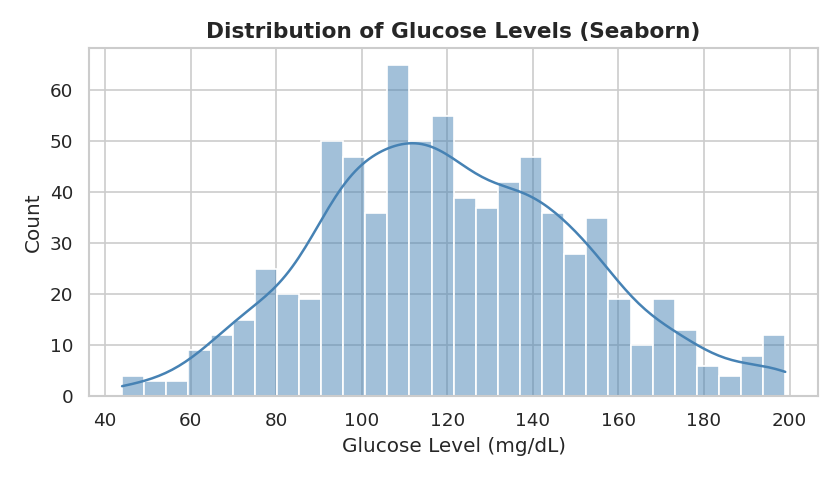

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['Glucose'], bins=30, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Glucose Levels (Seaborn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Glucose Level (mg/dL)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Seaborn Chart 2: Scatter Plot


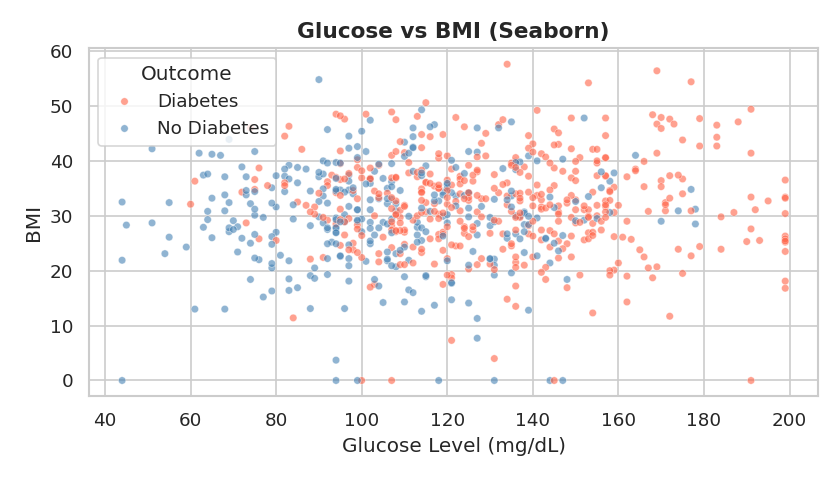

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='OutcomeLabel',
                palette={'No Diabetes': 'steelblue', 'Diabetes': 'tomato'},
                alpha=0.6, s=20, ax=ax)
ax.set_title('Glucose vs BMI (Seaborn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Glucose Level (mg/dL)')
ax.set_ylabel('BMI')
ax.legend(title='Outcome')
plt.tight_layout()
plt.show()

### Seaborn Chart 3: Bar Chart with Error Bars


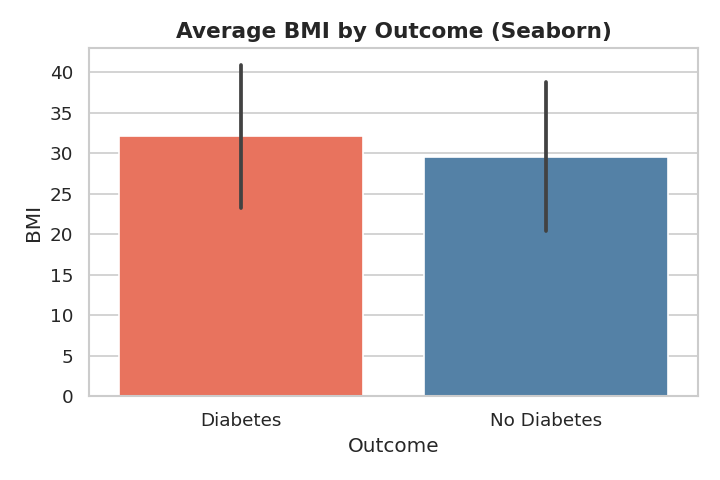

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x='OutcomeLabel', y='BMI', hue='OutcomeLabel',
            palette={'No Diabetes': 'steelblue', 'Diabetes': 'tomato'},
            ax=ax, errorbar='sd', legend=False)
ax.set_title('Average BMI by Outcome (Seaborn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('BMI')
plt.tight_layout()
plt.show()

### Seaborn Chart 4: Box Plot


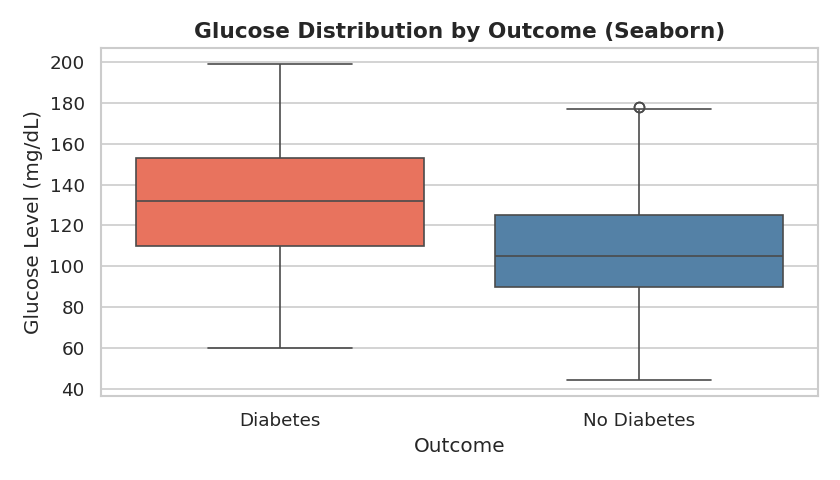

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='OutcomeLabel', y='Glucose', hue='OutcomeLabel',
            palette={'No Diabetes': 'steelblue', 'Diabetes': 'tomato'},
            ax=ax, legend=False)
ax.set_title('Glucose Distribution by Outcome (Seaborn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Glucose Level (mg/dL)')
plt.tight_layout()
plt.show()

### Seaborn Chart 5: Line Chart


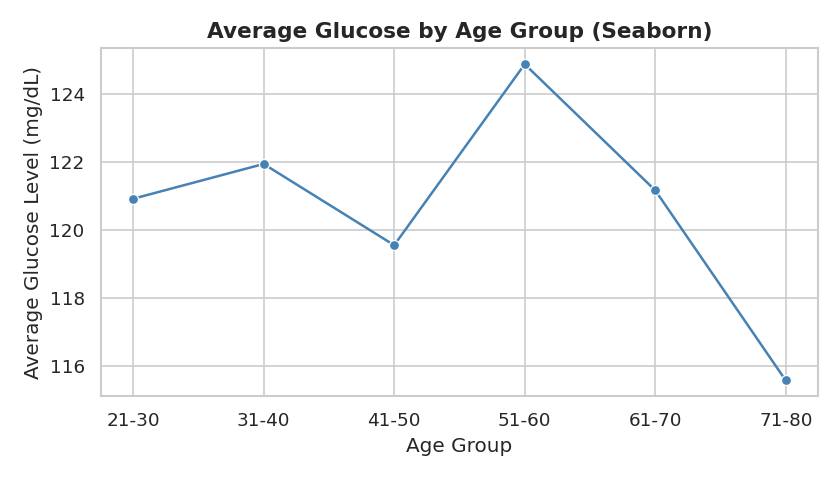

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=age_glucose.index.astype(str),
             y=age_glucose.values, marker='o', ax=ax, color='steelblue')
ax.set_title('Average Glucose by Age Group (Seaborn)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Glucose Level (mg/dL)')
plt.tight_layout()
plt.show()

### Matplotlib vs Seaborn — My Preference

**I prefer Seaborn** for exploratory data analysis like this project, for these reasons:

1. **Less boilerplate** — Seaborn's `histplot(kde=True)` adds a density curve automatically; with Matplotlib I'd need to compute and overlay it manually.
2. **Better defaults** — The `whitegrid` theme adds readable gridlines, and font sizing is more polished out of the box, requiring fewer `ax.set_*` calls.
3. **Built-in grouping** — `hue='OutcomeLabel'` handles colour-splitting and legend creation in one parameter; Matplotlib required a manual `Line2D` legend.
4. **Error bars for free** — The `errorbar='sd'` parameter on the bar chart shows variability without extra code.

That said, **Matplotlib gives more precise control** when I need exact positioning, custom annotations, or multi-panel layouts — so knowing both is valuable.


---
## Task 4 — Data Story


### My Three Data Questions

1. **Does glucose level affect diabetes outcome?**
2. **Which age group has the highest diabetes rate?**
3. **Is BMI linked to diabetes outcome?**


### Question 1: Does glucose level affect diabetes outcome?


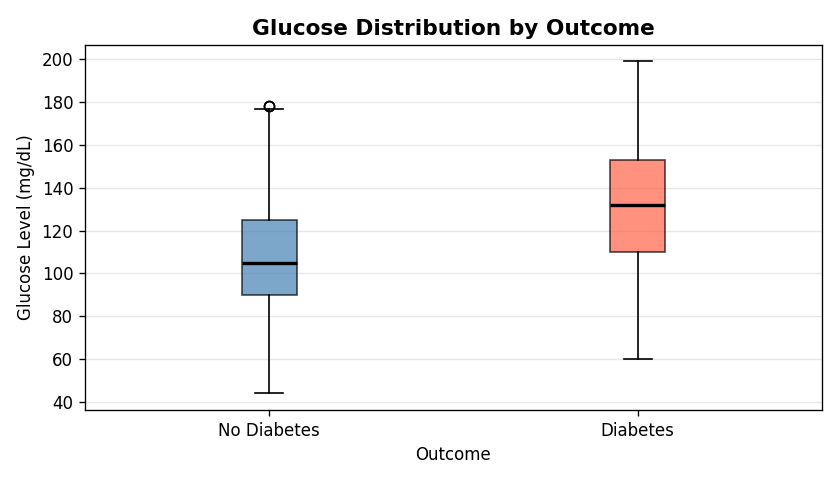

No diabetes avg glucose: 105.9 mg/dL
Diabetes avg glucose:    132.6 mg/dL
Difference:              26.7 mg/dL


In [ ]:
# Chart: Box plot of glucose by outcome
fig, ax = plt.subplots(figsize=(7, 5))
groups = [df[df['Outcome']==0]['Glucose'], df[df['Outcome']==1]['Glucose']]
bp = ax.boxplot(groups, tick_labels=['No Diabetes','Diabetes'],
                patch_artist=True,
                medianprops=dict(color='black',linewidth=2.5))
bp['boxes'][0].set_facecolor('#4e91c7'); bp['boxes'][1].set_facecolor('#e05c4a')
for p in bp['boxes']: p.set_alpha(0.75)
ax.set_title('Q1: Glucose Level by Diabetes Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Finding
no_d = df[df['Outcome']==0]['Glucose'].mean()
d = df[df['Outcome']==1]['Glucose'].mean()
print(f'No diabetes avg glucose: {no_d:.1f} mg/dL')
print(f'Diabetes avg glucose:    {d:.1f} mg/dL')
print(f'Difference:              {d-no_d:.1f} mg/dL')

> **Finding:** Patients with diabetes had an average glucose level of **132.6 mg/dL**, compared to **105.9 mg/dL** for non-diabetic patients — a difference of 26.7 mg/dL, confirming glucose level is a strong indicator of diabetes.


### Question 2: Which age group has the highest diabetes rate?


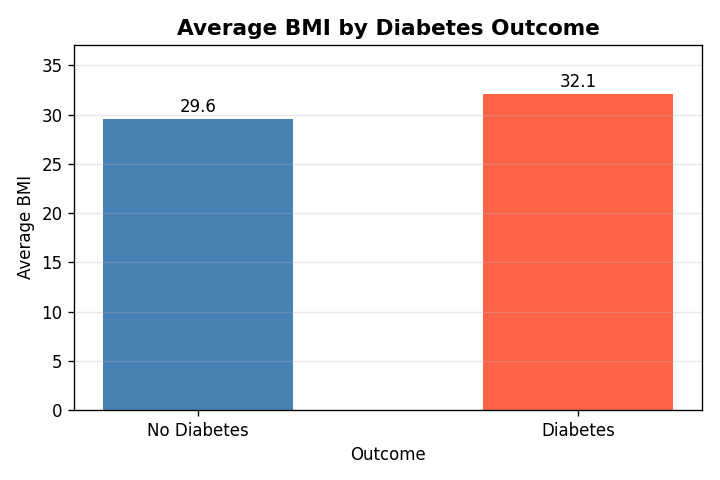

AgeGroup
21-30    48.5
31-40    57.9
41-50    64.3
51-60    68.1
61-70    70.4
71-80    65.2

Highest rate: 61-70 age group at 70.4%


In [ ]:
# Chart: Bar chart of diabetes rate by age group
diabetes_rate = df.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(diabetes_rate.index.astype(str), diabetes_rate.values,
              color='steelblue', edgecolor='white')
ax.set_title('Q2: Diabetes Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Diabetes Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(diabetes_rate.round(1).to_string())
print(f'\nHighest rate: {diabetes_rate.idxmax()} age group at {diabetes_rate.max():.1f}%')

> **Finding:** The **61–70 age group** had the highest diabetes rate at **70.4%**, and rates increase steadily with age — patients over 60 were almost twice as likely to have diabetes as patients in their 20s (48.5%).


### Question 3: Is BMI linked to diabetes outcome?


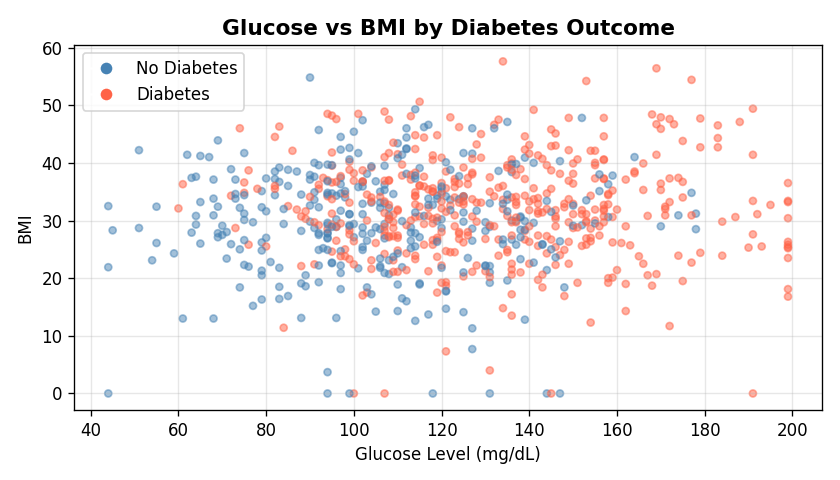

Avg BMI — No Diabetes: 29.59  |  Diabetes: 32.10
% Obese (BMI≥30) — No Diabetes: 45.3%  |  Diabetes: 63.5%


In [ ]:
# Chart: Scatter of BMI vs Glucose, coloured by outcome
fig, ax = plt.subplots(figsize=(8, 5))
for outcome, color, label in [(0,'steelblue','No Diabetes'),(1,'tomato','Diabetes')]:
    subset = df[df['Outcome']==outcome]
    ax.scatter(subset['BMI'], subset['Glucose'], c=color, alpha=0.5, s=18, label=label)
ax.axvline(x=30, color='gray', linestyle='--', linewidth=1, label='BMI 30 (Obese threshold)')
ax.set_title('Q3: BMI vs Glucose by Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

bmi_no_d = df[df['Outcome']==0]['BMI'].mean()
bmi_d = df[df['Outcome']==1]['BMI'].mean()
pct_obese_d = (df[df['Outcome']==1]['BMI']>=30).mean()*100
pct_obese_no_d = (df[df['Outcome']==0]['BMI']>=30).mean()*100
print(f'Avg BMI — No Diabetes: {bmi_no_d:.2f}  |  Diabetes: {bmi_d:.2f}')
print(f'% Obese (BMI≥30) — No Diabetes: {pct_obese_no_d:.1f}%  |  Diabetes: {pct_obese_d:.1f}%')

> **Finding:** Diabetic patients had an average BMI of **32.10** vs **29.59** for non-diabetic patients, and **63.5%** of diabetic patients were classified as obese (BMI ≥ 30), compared to only 45.3% of non-diabetic patients — confirming a clear link between obesity and diabetes in this dataset.


---
## What I Would Explore Next

1. **Interaction effects** — I would investigate whether high glucose *combined with* high BMI is a stronger predictor than either variable alone, using a logistic regression model or a correlation heatmap across all features.

2. **Temporal and lifestyle data** — I would combine this dataset with dietary data, physical activity levels, or socioeconomic indicators from open public health datasets (e.g. NHANES) to understand *why* glucose and BMI are elevated, not just *that* they are.

3. **Predictive modelling** — With clean features identified through this EDA, the natural next step would be building a simple classification model (e.g. a decision tree or logistic regression) to predict diabetes outcome, and evaluating it with precision, recall, and AUC-ROC to measure real-world usefulness.


---
## Task 5 — GitHub Publishing Checklist

Before pushing, verify the following:

- [ ] Run **Kernel → Restart & Run All** to ensure all cells execute cleanly from top to bottom
- [ ] All chart outputs are visible (not empty) after running
- [ ] No error messages in any cell output
- [ ] `diabetes.csv` is in the same folder as the notebook in the repo
- [ ] Commit both `wk1_project.ipynb` and `diabetes.csv` to the repo
- [ ] Open the notebook URL on GitHub and confirm charts render inline

**GitHub commit command:**
```bash
git add wk1_project.ipynb diabetes.csv
git commit -m "Add wk1 project: diabetes EDA with 5 chart types and data story"
git push origin main
```
